# PyTorch Introduction

We're going to spend today walking through [PyTorch](https://pytorch.org), a popular open-source library for deep learning. We're talking about PyTorch because I prefer it. Others prefer TensorFlow, but that number is dwindling. Others prefer JAX, particularly in the research community, but it's a small fraction. 

In general, PyTorch has good documentation, good built-in functionality, and a wide network of compatible libraries that make Deep Learning easier to get up and running. It also exposes a bit more of the machinery to the user which makes it more customizable, particularly for things that aren't vanilla supervised learning.

There are some subtle under-the-hood differences between PyTorch and TensorFlow. I may get into those details next time, or maybe not.

## Step 0 - make sure PyTorch is installed

In [1]:
%pip install torch

Note: you may need to restart the kernel to use updated packages.


In [2]:
import torch
import numpy as np

print(f'PyTorch version: {torch.__version__}')

PyTorch version: 2.8.0


In [4]:
# Check available hardware
if torch.cuda.is_available():
    print(f'GPU is available, using GPU {torch.cuda.get_device_name(0)}')
elif torch.mps.is_available():
    print(f'Apple Metal Performance Shaders framework is available, using {torch.device("mps")}')
else:
    print(f'Hardware acceleration not available, using CPU')

Apple Metal Performance Shaders framework is available, using mps


## Torch Tensors

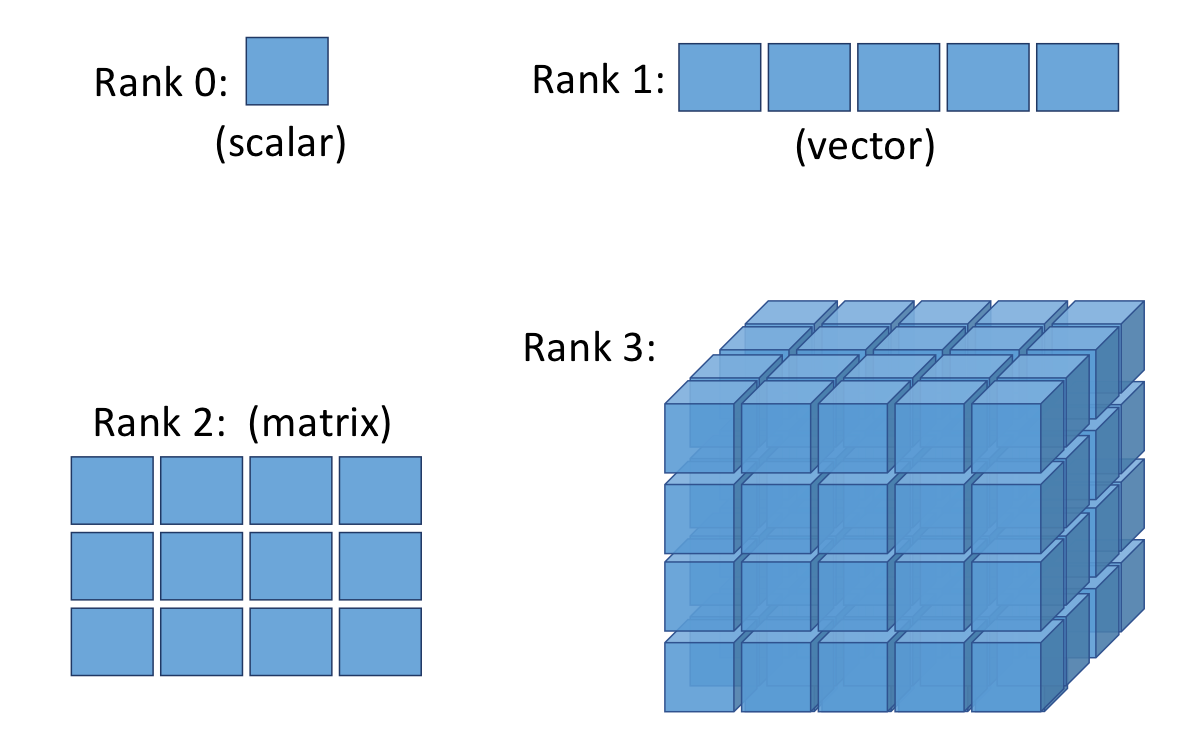

The basic unit of operation in (py)torch is a **tensor**. A tensor is a generalization of a scalar or vector. There are very precise mathematical definitions of tensors that for the purposes of this course do not really matter at all. 

On a computer, a tensor is basically a group of elements that can be indexed. A **scalar** is a rank-0 tensor. It has no index. A **vector** is a rank-1 tensor that can be indexed as $\vec{V}: V_i$. A **matrix** is a rank-2 tensor that can be indexed as $\overleftrightarrow{M}: M_{ij}$. A rank-3 tensor is similarly indexed as $T_{ijk}$.

We see tensors a lot in deep learning because we are often dealing with data structures with a particular shape and number of indices. For example, in the tutorial last week we saw how important it was to keep track of the shape and dimension of each variable in our MLP.

In [7]:
a1 = [1, 2, 3]
a2 = np.array([1, 2, 3], dtype=np.float32)

t1 = torch.tensor(a1)
t2 = torch.tensor(a2)

print(t1)
print(t2)

tensor([1, 2, 3])
tensor([1., 2., 3.])


It is not unreasonable to think about tensors as torch wrappers around numpy ndarrays. They behave quite similarly, although they carry a bit more information along with them

In [13]:
a3 = np.eye(3, dtype=np.float32)
t3 = torch.from_numpy(a3)
print(t3.shape, t3.dtype, t3.device, t3.grad)

torch.Size([3, 3]) torch.float32 cpu None


We can do a lot of things with tensors, like reshape them, change their data type, and change the device that they reside on

In [14]:
t3_1 = t3.reshape([9, 1])
t3_2 = t3.bool()
t3_3 = t3.to(torch.device('mps'))

print(t3_1)
print(t3_2)
print(t3_3)

tensor([[1.],
        [0.],
        [0.],
        [0.],
        [1.],
        [0.],
        [0.],
        [0.],
        [1.]])
tensor([[ True, False, False],
        [False,  True, False],
        [False, False,  True]])
tensor([[1., 0., 0.],
        [0., 1., 0.],
        [0., 0., 1.]], device='mps:0')


Tensors can get very large and have a large number of indices. For example, a batch of images might have 4 indices: $[B, C, H, W]$

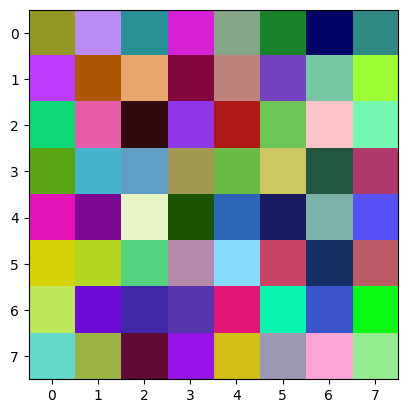

In [19]:
t_big = torch.rand(1, 3, 8, 8)

%matplotlib inline
import matplotlib.pyplot as plt
ax = plt.figure().gca()
ax.imshow(t_big.squeeze().permute(1, 2, 0))

We can do a lot of normal mathematical and array operations with tensors just as we would numpy arrays

In [31]:
t1 = torch.rand(3, 2)
t2 = torch.normal(mean=0, std=1, size=(3, 2))

t3 = t1 * t2 # Elementwise product
print(t3, t3.shape)

t4 = t1.mean(dim=1) # Mean along dimension
print(t4, t4.shape)

t5 = torch.matmul(t1.T, t2) # Matrix multiplication
print(t5, t5.shape)

t6 = torch.linalg.norm(t2) # L2 norm
print(t6, t6.shape)

tensor([[-0.0087, -0.5101],
        [ 0.3635, -1.2957],
        [ 0.3731, -0.1397]]) torch.Size([3, 2])
tensor([0.3081, 0.6767, 0.2608]) torch.Size([3])
tensor([[ 0.7278, -1.1021],
        [ 0.5017, -1.9454]]) torch.Size([2, 2])
tensor(2.6225) torch.Size([])


In [36]:
print(t1.shape, t2.shape)

# Tensor concatenation
t3 = torch.concat([t1, t2], dim=1)
print(t3.shape)

# Tensor splitting
t4, t5 = torch.split(t3, 2, dim=1)
print(t4.shape, torch.all(t1 == t4))
print(t5.shape, torch.all(t2 == t5))

# Tensor stacking
t6 = torch.stack([t1, t2], dim=0)
print(t6.shape)

torch.Size([3, 2]) torch.Size([3, 2])
torch.Size([3, 4])
torch.Size([3, 2]) tensor(True)
torch.Size([3, 2]) tensor(True)
torch.Size([2, 3, 2])


## Torch Datasets and DataLoaders

Torch builds in a lot of functionality that we need for training neural networks beyond the networks themselves (which we will get to). For example, data loading pipelines to serve tensors to the model during training

In [41]:
from torch.utils.data import Dataset
class BasicDataset(Dataset):
    def __init__(self, x, y):
        self.x = x
        self.y = y

    def __len__(self):
        """ So torch code knows how many examples to fetch from the dataset """
        return self.x.shape[0]

    def __getitem__(self, idx):
        """ So torch code knows how to access the underlying data """
        return self.x[idx], self.y[idx]

# A torch Dataset can be accessed just like an array now
dataset = BasicDataset(
    x=torch.rand([10, 4]),
    y=torch.arange(10, dtype=torch.long)
)

print(f"The size of the dataset is {len(dataset)}")
print(f"The 4th element of the dataset is {dataset[3]}")

The size of the dataset is 10
The 4th element of the dataset is (tensor([0.1177, 0.2501, 0.2169, 0.1876]), tensor(3))


In [42]:
from torch.utils.data import TensorDataset

tensor_dataset = TensorDataset(dataset.x, dataset.y)
print(f"The size of the dataset is {len(dataset)}")
print(f"The 4th element of the dataset is {dataset[3]}")

The size of the dataset is 10
The 4th element of the dataset is (tensor([0.1177, 0.2501, 0.2169, 0.1876]), tensor(3))


In [49]:
from torch.utils.data import DataLoader

loader = DataLoader(dataset=dataset, batch_size=2, shuffle=True)
for ii, batch in enumerate(loader):
    print(f"Batch {ii}: x={batch[0]}\n\t y={batch[1]}")

Batch 0: x=tensor([[0.4150, 0.1792, 0.7571, 0.4800],
        [0.5858, 0.2494, 0.3089, 0.5868]])
	 y=tensor([2, 9])
Batch 1: x=tensor([[0.7750, 0.3791, 0.2034, 0.5090],
        [0.4385, 0.7999, 0.6112, 0.8075]])
	 y=tensor([6, 8])
Batch 2: x=tensor([[0.8527, 0.6044, 0.3551, 0.7841],
        [0.1177, 0.2501, 0.2169, 0.1876]])
	 y=tensor([5, 3])
Batch 3: x=tensor([[0.7314, 0.0097, 0.7181, 0.6203],
        [0.6304, 0.2727, 0.7043, 0.2928]])
	 y=tensor([7, 4])
Batch 4: x=tensor([[0.8928, 0.1616, 0.1701, 0.3471],
        [0.1429, 0.0171, 0.8617, 0.0248]])
	 y=tensor([1, 0])


In [50]:
for epoch in range(2):
    print(f"Epoch {epoch}")
    for ii, batch in enumerate(loader):
        print(f"\tBatch {ii}: x={batch[0]}\n\t\t y={batch[1]}")

Epoch 0
	Batch 0: x=tensor([[0.8928, 0.1616, 0.1701, 0.3471],
        [0.4385, 0.7999, 0.6112, 0.8075]])
		 y=tensor([1, 8])
	Batch 1: x=tensor([[0.4150, 0.1792, 0.7571, 0.4800],
        [0.1177, 0.2501, 0.2169, 0.1876]])
		 y=tensor([2, 3])
	Batch 2: x=tensor([[0.5858, 0.2494, 0.3089, 0.5868],
        [0.7314, 0.0097, 0.7181, 0.6203]])
		 y=tensor([9, 7])
	Batch 3: x=tensor([[0.6304, 0.2727, 0.7043, 0.2928],
        [0.8527, 0.6044, 0.3551, 0.7841]])
		 y=tensor([4, 5])
	Batch 4: x=tensor([[0.7750, 0.3791, 0.2034, 0.5090],
        [0.1429, 0.0171, 0.8617, 0.0248]])
		 y=tensor([6, 0])
Epoch 1
	Batch 0: x=tensor([[0.7750, 0.3791, 0.2034, 0.5090],
        [0.1177, 0.2501, 0.2169, 0.1876]])
		 y=tensor([6, 3])
	Batch 1: x=tensor([[0.8527, 0.6044, 0.3551, 0.7841],
        [0.6304, 0.2727, 0.7043, 0.2928]])
		 y=tensor([5, 4])
	Batch 2: x=tensor([[0.7314, 0.0097, 0.7181, 0.6203],
        [0.4150, 0.1792, 0.7571, 0.4800]])
		 y=tensor([7, 2])
	Batch 3: x=tensor([[0.4385, 0.7999, 0.6112, 0.8

## Multiprocessing is really easy now

In [75]:
dataset = TensorDataset(
    torch.rand([8192, 3, 128, 128]),
    torch.arange(8192, dtype=torch.long)
)
print(len(dataset))

8192


In [76]:
%%time
loader = DataLoader(dataset, batch_size=128, num_workers=0)
for epoch in range(5):
    t = time()
    for ii, batch in enumerate(loader):
        assert len(batch[0]) == 128
    print(f"Epoch {epoch}: {time()-t:.3f} s")

Epoch 0: 0.308 s
Epoch 1: 0.298 s
Epoch 2: 0.289 s
Epoch 3: 0.290 s
Epoch 4: 0.290 s
CPU times: user 924 ms, sys: 3.64 s, total: 4.56 s
Wall time: 1.64 s


In [77]:
from time import time
loader = DataLoader(dataset, batch_size=128, num_workers=2, persistent_workers=True)
for epoch in range(5):
    t = time()
    for ii, batch in enumerate(loader):
        assert len(batch[0]) == 128
    print(f"Epoch {epoch}: {time()-t:.3f} s")

Epoch 0: 1.210 s
Epoch 1: 0.070 s
Epoch 2: 0.068 s
Epoch 3: 0.069 s
Epoch 4: 0.074 s
